# Coincidence matrix

## Imports and Definitions

In [129]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [2]:
# plot settings, increase font sizes
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 15, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Read Data

In [154]:
fileDir = "/Users/andyyu/Documents/Python/HEP/dawson_hep/scintillating_chamber/data_analysis/data"

In [113]:
runNo = 297

# data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in (17, 27)], signal_filter='converted')

data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')

for i in data.waveforms:
    print(i)

timestamp
waveTime
wave
amplitude
amplitudeTime
integral
tot
cft
intensity


In [ ]:
"""
timestamp: seconds UTC
waveTime: sample time
wave: [event, ch, samples(number of poitns captured)]
    we can do data.max(axis = 2) >>> [10000,10]
amplitude: 
amplitudeTime: 
integral: sensor charge
tot: time over threshold, 
cft: 
intensity: 
"""

In [ ]:


def getMaxMask(data):

    ch_event = getMask(0, data)

    for _channel_trigger in range(1,10):

        masked = getMask(_channel_trigger, data)


        if masked[0].shape[0] > ch_event[0].shape[0]:
            ch_event = masked
    

    return ch_event[0]

def getMask(_channel_trigger, data):

    """"
    HAVE TO FIX: CHANNEL 0-5 8mV threshold, 6-9: 6mV threshold
    """
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    mask_event = (signal_min > -15) & (signal_max > 10)

    return np.where(mask_event)

print(getMaxMask(data))

# rate = selected_events / len(data.waveforms['wave'])
# print(f"{len(selected_events)} signal events of {len(data.waveforms['wave'])} total events")



# n = 24
# (triggered_event_n,) = np.argwhere(mask_event)[n]
# print(triggered_event_n)

# mask_event = np.zeros(len(mask_event), dtype=bool)
# mask_event[triggered_event_n] = 1

# for ch in range(10):
#     print(data.waveforms['waveTime'][mask_event, ch].T),
#     print(data.waveforms['wave'][mask_event, ch].T)

print(np.argwhere(getMaxMask(data)))
# print(np.argwhere(mask_event))


[   2    5   11 ... 9996 9998 9999]
[[   0]
 [   1]
 [   2]
 ...
 [2641]
 [2642]
 [2643]]


In [ ]:
"""
for every wave data.waveforms['wave']


matrix[0][3] += 1

np.argwhere(mask_event)[n]

"""

In [139]:

def getPairs(mask_event):
    trigger_sets = []
    for i in np.argwhere(mask_event):
        
        i = i[0]


        pair = []
        for k in range(10):


            if data.waveforms["wave"][index][k].max() > 8:
                pair.append(k)
            

            trigger_sets.append(pair)

    # print(trigger_sets)

    trigger_pairs = []
    for i in trigger_sets:
        if len(i) == 2:
            trigger_pairs.append(i)

    return trigger_pairs


# trigger_pairs(mask_event)

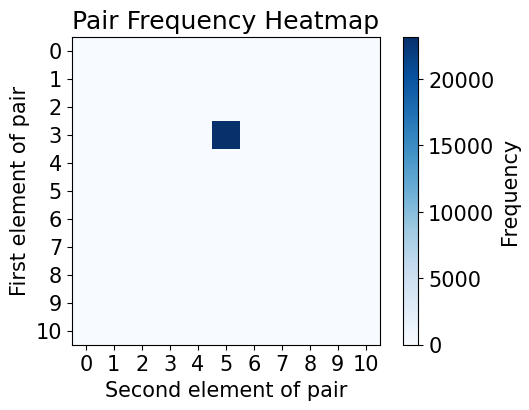

In [ ]:

pairs = trigger_pairs

# count the number of unique pairs and convert into a dictionary
pair_counts = Counter(tuple(p) for p in pairs)

# find max index to size the matrix
max_idx = 10

# build matrix
matrix = np.zeros((max_idx+1, max_idx+1), dtype=int)
for (i, j), count in pair_counts.items():
    matrix[i, j] = count


plt.imshow(matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Frequency")
plt.xlabel("Second element of pair")
plt.ylabel("First element of pair")
plt.title("Pair Frequency Heatmap")

plt.xticks(np.arange(matrix.shape[1]))  # 0,1,2 for 3 columns
plt.yticks(np.arange(matrix.shape[0]))  # 0,1,2 for 3 rows

plt.show()

/var/folders/g3/v7y9h9s955v66q681bphnb740000gn/T/ipykernel_37490/1826397336.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


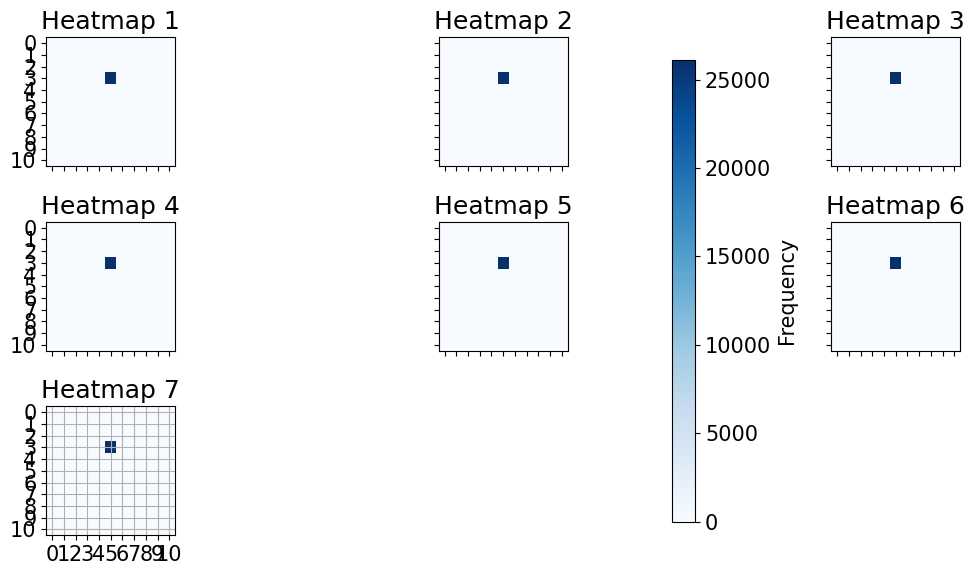

: 

In [ ]:
run_start = 297
run_end = 303

number_of_runs = run_end - run_start + 1

data_files = []
for runNo in range(run_start, run_end + 1):
    data_files.append(digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted'))


num_col = 3
num_row = number_of_runs // num_col + 1
fig, axes = plt.subplots(num_row,num_col, figsize = (12,6), sharex=True, sharey=True)

axes = axes.flatten()

# find max index to size the matrix(number of channels)
max_idx = 10

for i in range(len(data_files)):

    #Get the selected events
    mask_event = getMaxMask(data_files[i])

    #Get the pairs
    pairs = getPairs(mask_event)

    # count the number of unique pairs and convert into a dictionary
    pair_counts = Counter(tuple(p) for p in pairs)
    


    # build matrix
    matrix = np.zeros((max_idx+1, max_idx+1), dtype=int)
    for (j, k), count in pair_counts.items():
        matrix[j, k] = count
    

    # plot heatmap in the subplot
    ax = axes[i]
    im = ax.imshow(matrix, cmap="Blues", interpolation="nearest")
    ax.set_title(f"Heatmap {i+1}")
    
    # set x and y ticks
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_yticks(np.arange(matrix.shape[0]))

# remove unused subplots
for j in range(number_of_runs, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(right=0.85)
cbar = fig.colorbar(im, ax=axes[:number_of_runs].tolist(), label="Frequency")

plt.grid(True)
plt.tight_layout()
plt.show()

In [112]:
run_start = 297
run_end = 303

number_of_runs = run_start - run_end
data_files = []
for runNo in range(run_start, run_end + 1):
    data_files.append(digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted'))

KeyboardInterrupt: 

In [ ]:
runNo = 1
data = digitizer(f'{fileDir}/run{runNo:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')

